In [1]:
# ---------------------------------------------------------------------------
# From prediction to decision: maintenance scheduling
# ---------------------------------------------------------------------------
# 02 ends with a predicted RUL per engine. A planner cannot act on that directly
# -- the question on their desk is "which engines go into the shop this week?",
# and the shop has limited capacity.
#
# This notebook turns predictions into schedules and, because the true RUL of the
# test engines is known, scores what those schedules actually cost.
import sys
sys.path.append('..')  # so `import src` resolves from the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ortools.sat.python import cp_model

predictions = pd.read_csv('../outputs/test_predictions.csv')
val_errors = pd.read_csv('../outputs/lstm_val_errors.csv')['d'].values
rolling = pd.read_csv('../outputs/rolling_predictions.csv')

print("Engines:", len(predictions))
print("Cross-fitted engine residuals for the uncertainty model:", len(val_errors))
predictions.head()

Engines: 100
Cross-fitted engine residuals for the uncertainty model: 80


,unit,rul_true,rul_true_capped,pred_lr,pred_rf,pred_xgb,pred_lstm
0,1,112.0,112.0,124.597198,122.220018,123.496080,121.844050
1,2,98.0,98.0,102.482038,118.562060,120.057930,121.827380
2,3,69.0,69.0,74.225230,47.782972,44.839725,45.034730
3,4,82.0,82.0,78.711659,95.622977,90.873055,120.379585
4,5,91.0,91.0,88.662654,108.319810,107.092030,85.445700


In [2]:
# --- problem parameters -----------------------------------------------------
# HORIZON: how far ahead we plan, in cycles.
# CAPACITY: engines the shop can take per cycle. Scarcity here is what makes
#   scheduling a decision rather than a lookup.
# FAILURE_COST vs WASTE_COST: an unplanned in-service failure costs 100x one
#   wasted cycle of remaining life -- the same asymmetry the NASA score encodes.
HORIZON = 30
CAPACITY = 3
FAILURE_COST = 100
WASTE_COST = 1

rul_true = predictions['rul_true'].values
rul_pred = predictions['pred_lstm'].values
N_ENGINES = len(rul_true)

print("Slots available:", HORIZON * CAPACITY, "for", N_ENGINES, "engines")
print("Engines that truly fail within the horizon:", (rul_true <= HORIZON).sum())
print("Engines the LSTM thinks are critical:      ", (rul_pred <= HORIZON).sum())

Slots available: 90 for 100 engines
Engines that truly fail within the horizon: 25
Engines the LSTM thinks are critical:       19


In [3]:
def evaluate_schedule(schedule, rul_actual, horizon=HORIZON):
    """Score a schedule against the RUL that actually happened.

    schedule maps engine index -> service period, or None if deferred past the
    window. This function is the only judge in the notebook, and it never sees
    any prediction -- every strategy below is scored on the same real outcome.
    """
    from src.scheduling import evaluate_schedule as _evaluate_schedule
    return _evaluate_schedule(schedule, rul_actual, horizon, FAILURE_COST, WASTE_COST)

In [4]:
# --- two ways to price a maintenance slot -----------------------------------
# The optimiser needs cost[i][t] (servicing engine i in period t) and a cost for
# deferring it. How those numbers are built is the whole story of this notebook.
# Implementations live in src/scheduling.py; these wrappers keep the notebook's
# own HORIZON/CAPACITY/FAILURE_COST/WASTE_COST as the single source of truth.
from src.scheduling import point_estimate_costs as _point_estimate_costs
from src.scheduling import expected_costs as _expected_costs


def point_estimate_costs(rul_estimate, horizon=HORIZON):
    """Treat the predicted RUL as if it were the truth."""
    return _point_estimate_costs(rul_estimate, horizon, FAILURE_COST, WASTE_COST)


# Use a fixed quantile representation of the engine-level cross-fitted error
# distribution. It keeps the shape and makes bootstrap rebuilding predictable.
ERROR_QUANTILES = np.percentile(val_errors, np.linspace(0, 100, 400))


def expected_costs(pred, errors=None, horizon=HORIZON):
    """Price each slot against the model's whole error distribution."""
    errors = ERROR_QUANTILES if errors is None else errors
    return _expected_costs(pred, errors, horizon, FAILURE_COST, WASTE_COST)

In [5]:
def solve_schedule(cost, defer, horizon=HORIZON, capacity=CAPACITY, verbose=False):
    """Exact maintenance schedule via CP-SAT, given a priced cost matrix."""
    from src.scheduling import solve_schedule as _solve_schedule
    return _solve_schedule(cost, defer, horizon, capacity, verbose)

In [6]:
# --- baselines ---------------------------------------------------------------
# fixed_interval_schedule: calendar-based preventive maintenance, ignoring
#   condition data entirely -- what predictive maintenance is meant to beat.
# greedy_schedule: most urgent engine first, booked as late as safely possible.
#   Myopic -- never revisits an earlier booking when urgency shows up later.
# threshold_schedule: the honest competitor -- service everything predicted
#   below a cut-off, soonest first. No solver, no cost model, one number.
from src.scheduling import fixed_interval_schedule as _fixed_interval_schedule
from src.scheduling import greedy_schedule as _greedy_schedule
from src.scheduling import threshold_schedule as _threshold_schedule


def fixed_interval_schedule(n, horizon=HORIZON, capacity=CAPACITY):
    return _fixed_interval_schedule(n, horizon, capacity)


def greedy_schedule(rul_estimate, horizon=HORIZON, capacity=CAPACITY):
    return _greedy_schedule(rul_estimate, horizon, capacity)


def threshold_schedule(rul_estimate, threshold, horizon=HORIZON, capacity=CAPACITY):
    return _threshold_schedule(rul_estimate, threshold, horizon, capacity)

In [7]:
# --- the safety margin ------------------------------------------------------
# A middle ground between trusting the point estimate and modelling the whole
# distribution: shift every prediction down by a fixed number of cycles.
#
# The margin is read off cross-fitted training-engine errors. Reading it off the test outcome
# would be tuning on the set we report on -- the same mistake the test-set
# evaluation in 02 was added to avoid.
for q in [50, 75, 90, 95, 99]:
    print(f'  {q}th percentile of d: {np.percentile(val_errors, q):6.2f}')

SAFETY_QUANTILE = 90       # chosen a priori: cover 90% of the error distribution
safety_margin = np.percentile(val_errors, SAFETY_QUANTILE)
rul_robust = np.maximum(rul_pred - safety_margin, 0)

print(f'\nSafety margin ({SAFETY_QUANTILE}th pct): {safety_margin:.2f} cycles')
print(f'Engines treated as critical: {(rul_robust <= HORIZON).sum()} (was {(rul_pred <= HORIZON).sum()})')

  50th percentile of d:   1.43
  75th percentile of d:  10.19
  90th percentile of d:  26.04
  95th percentile of d:  29.82
  99th percentile of d:  45.28

Safety margin (90th pct): 26.04 cycles
Engines treated as critical: 33 (was 19)


In [8]:
# --- run every strategy -----------------------------------------------------
strategies = {}
strategies['Fixed interval'] = fixed_interval_schedule(N_ENGINES)
strategies['Greedy (raw)'] = greedy_schedule(rul_pred)
strategies['Greedy (margin)'] = greedy_schedule(rul_robust)

# Sweep the threshold and keep the best. Note this tunes on the test outcome, so
# it flatters the policy -- it is an upper bound on what the family can do, which
# is exactly what we want it to be as a competitor.
threshold_sweep = pd.DataFrame([
    {'threshold': thr, **evaluate_schedule(threshold_schedule(rul_pred, thr), rul_true)}
    for thr in [10, 15, 20, 25, 30, 40, 50]
])
best_threshold = int(threshold_sweep.loc[threshold_sweep['total_cost'].idxmin(), 'threshold'])
print('Threshold sweep (tuned on test, so optimistic):')
print(threshold_sweep.to_string(index=False))
print(f'best threshold: {best_threshold}\n')

strategies[f'Threshold (<={best_threshold}, tuned)'] = threshold_schedule(rul_pred, best_threshold)

print('CP-SAT, raw predictions:')
strategies['CP-SAT (raw)'] = solve_schedule(*point_estimate_costs(rul_pred), verbose=True)

print('CP-SAT, safety margin:')
strategies['CP-SAT (margin)'] = solve_schedule(*point_estimate_costs(rul_robust), verbose=True)

print('CP-SAT, expected cost over the error distribution:')
strategies['CP-SAT (expected cost)'] = solve_schedule(*expected_costs(rul_pred, val_errors), verbose=True)

# Upper bound: a planner with a perfect crystal ball. Unreachable, but it shows
# how much of the remaining gap is prediction error rather than bad scheduling.
print('CP-SAT, perfect information:')
strategies['CP-SAT (perfect info)'] = solve_schedule(*point_estimate_costs(rul_true), verbose=True)

results = pd.DataFrame([
    {'strategy': name, **evaluate_schedule(sched, rul_true)}
    for name, sched in strategies.items()
])
results['scheduled'] = [sum(1 for v in s.values() if v is not None) for s in strategies.values()]
results = results.sort_values('total_cost').reset_index(drop=True)
results

Threshold sweep (tuned on test, so optimistic):
 threshold  failures  wasted_life  total_cost
        10        21           28        2128
        15        19           41        1941
        20        15           86        1586
        25         7          200         900
        30         7          231         931
        40         1          361         461
        50         0          476         476
best threshold: 40

CP-SAT, raw predictions:
  OPTIMAL  planned cost=10  0.02s
CP-SAT, safety margin:
  OPTIMAL  planned cost=1806  0.02s
CP-SAT, expected cost over the error distribution:
  OPTIMAL  planned cost=982  0.01s
CP-SAT, perfect information:
  OPTIMAL  planned cost=1  0.01s


,strategy,failures,wasted_life,total_cost,scheduled
0,CP-SAT (perfect info),0,1,1,25
1,CP-SAT (expected cost),1,289,389,26
2,"Threshold (<=40, tuned)",1,361,461,26
3,Greedy (margin),0,575,575,33
4,CP-SAT (margin),0,604,604,34
5,Greedy (raw),19,20,1920,19
6,CP-SAT (raw),19,20,1920,21
7,Fixed interval,13,5512,6812,90


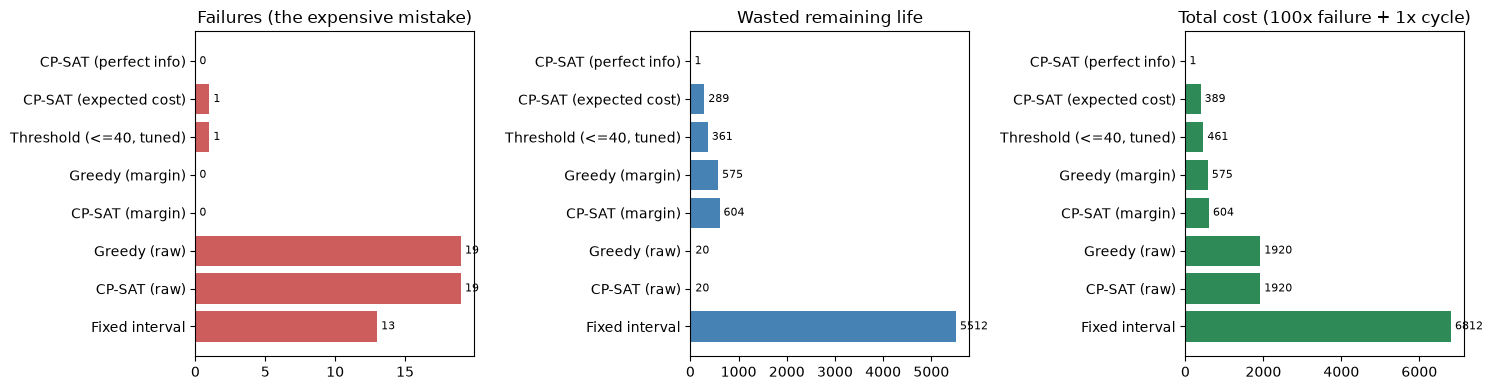

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
order = results['strategy'].tolist()

for axis, col, colour, title in [
    (ax[0], 'failures', 'indianred', 'Failures (the expensive mistake)'),
    (ax[1], 'wasted_life', 'steelblue', 'Wasted remaining life'),
    (ax[2], 'total_cost', 'seagreen', f'Total cost ({FAILURE_COST}x failure + 1x cycle)'),
]:
    axis.barh(order, results[col], color=colour)
    axis.invert_yaxis()
    axis.set_title(title)
    for y, v in enumerate(results[col]):
        axis.text(v, y, f' {v}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

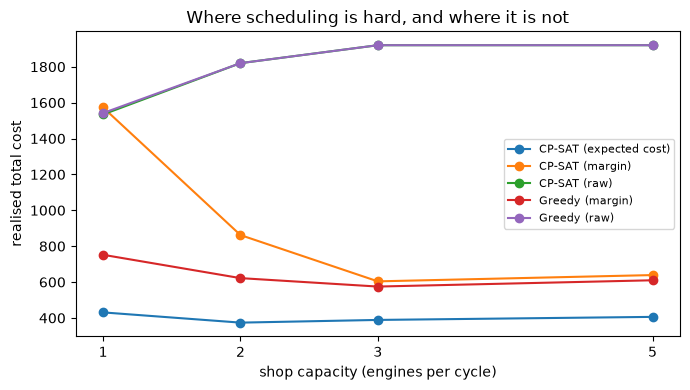

capacity,1,2,3,5
strategy,,,,
CP-SAT (expected cost),431,374,389,406
CP-SAT (margin),1573,862,604,639
CP-SAT (raw),1534,1820,1920,1920
Greedy (margin),752,622,575,610
Greedy (raw),1542,1820,1920,1920


In [10]:
# --- when does exact optimisation actually pay? -----------------------------
# The raw CP-SAT and greedy schedules tie at CAPACITY=3, which is worth taking
# seriously rather than glossing over: under those point estimates little is
# contended, so an exact solver has little to add over a sensible heuristic.
#
# Tightening capacity is the honest way to find out where the boundary is.
capacity_rows = []
for cap in [1, 2, 3, 5]:
    for name, sched in [
        ('Greedy (raw)', greedy_schedule(rul_pred, capacity=cap)),
        ('CP-SAT (raw)', solve_schedule(*point_estimate_costs(rul_pred), capacity=cap)),
        ('Greedy (margin)', greedy_schedule(rul_robust, capacity=cap)),
        ('CP-SAT (margin)', solve_schedule(*point_estimate_costs(rul_robust), capacity=cap)),
        ('CP-SAT (expected cost)', solve_schedule(*expected_costs(rul_pred, val_errors), capacity=cap)),
    ]:
        capacity_rows.append({'capacity': cap, 'strategy': name,
                              **evaluate_schedule(sched, rul_true)})

capacity_df = pd.DataFrame(capacity_rows)
capacity_pivot = capacity_df.pivot(index='strategy', columns='capacity', values='total_cost')

fig, ax = plt.subplots(figsize=(7, 4))
for name in capacity_pivot.index:
    ax.plot(capacity_pivot.columns, capacity_pivot.loc[name], 'o-', label=name)
ax.set_xlabel('shop capacity (engines per cycle)'); ax.set_ylabel('realised total cost')
ax.set_xticks(capacity_pivot.columns); ax.legend(fontsize=8)
ax.set_title('Where scheduling is hard, and where it is not')
plt.tight_layout(); plt.show()

capacity_pivot

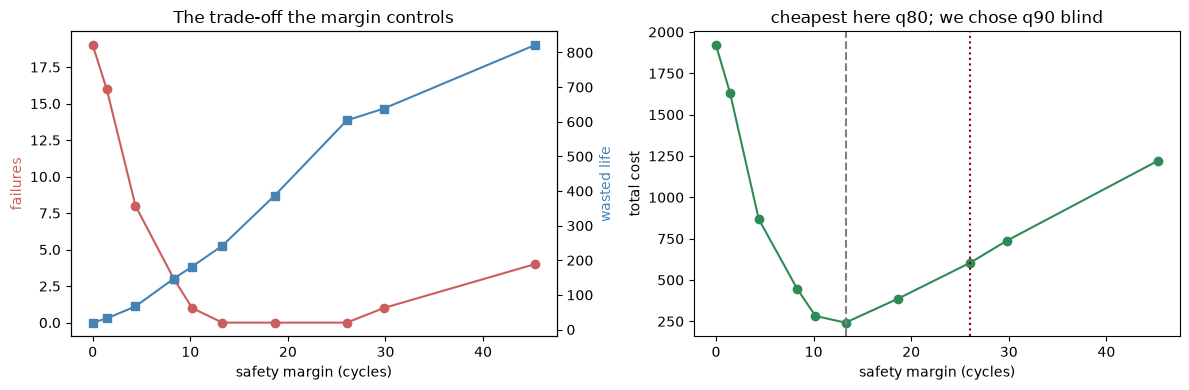

,quantile,margin,failures,wasted_life,total_cost
0,0,0.000000,19,20,1920
1,50,1.432722,16,32,1632
2,60,4.383725,8,67,867
3,70,8.311020,3,147,447
4,75,10.193215,1,182,282
5,80,13.275507,0,242,242
6,85,18.652233,0,387,387
7,90,26.040819,0,604,604
8,95,29.817481,1,638,738
9,99,45.279962,4,821,1221


In [11]:
# --- how much margin? -------------------------------------------------------
# Bigger margins pull maintenance forward: fewer failures, more life discarded.
# This sweep is a diagnostic, NOT how the margin above was chosen.
sweep = []
for q in [0, 50, 60, 70, 75, 80, 85, 90, 95, 99]:
    margin = max(np.percentile(val_errors, q), 0) if q > 0 else 0.0
    sched = solve_schedule(*point_estimate_costs(np.maximum(rul_pred - margin, 0)))
    sweep.append({'quantile': q, 'margin': margin, **evaluate_schedule(sched, rul_true)})

sweep_df = pd.DataFrame(sweep)
best = sweep_df.loc[sweep_df['total_cost'].idxmin()]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sweep_df['margin'], sweep_df['failures'], 'o-', color='indianred')
ax0b = ax[0].twinx()
ax0b.plot(sweep_df['margin'], sweep_df['wasted_life'], 's-', color='steelblue')
ax[0].set_xlabel('safety margin (cycles)')
ax[0].set_ylabel('failures', color='indianred'); ax0b.set_ylabel('wasted life', color='steelblue')
ax[0].set_title('The trade-off the margin controls')

ax[1].plot(sweep_df['margin'], sweep_df['total_cost'], 'o-', color='seagreen')
ax[1].axvline(best['margin'], linestyle='--', color='grey')
ax[1].axvline(safety_margin, linestyle=':', color='darkred')
ax[1].set_xlabel('safety margin (cycles)'); ax[1].set_ylabel('total cost')
ax[1].set_title(f"cheapest here q{int(best['quantile'])}; we chose q{SAFETY_QUANTILE} blind")
plt.tight_layout(); plt.show()

sweep_df

In [12]:
# ---------------------------------------------------------------------------
# Rolling horizon
# ---------------------------------------------------------------------------
# Everything above is a single static plan: decide once, never revisit. Real
# planning is rolling -- every cycle brings fresh sensor data, the prediction
# moves, and only the immediate decision is actually committed.
#
# 02 exported a prediction per engine per cycle for the last ROLL_CYCLES cycles
# of each test engine's record, which is what makes the simulation possible.
K = rolling['offset_from_end'].max() + 1
roll_units = sorted(rolling['unit'].unique())
n_roll = len(roll_units)

# pred_at[i, tau] = prediction for engine i at simulation cycle tau.
# offset counts backwards from truncation, so tau = 0 is the earliest point.
pivot_pred = rolling.pivot(index='unit', columns='offset_from_end', values='pred_lstm')
pivot_true = rolling.pivot(index='unit', columns='offset_from_end', values='rul_true')
pred_at = pivot_pred[sorted(pivot_pred.columns, reverse=True)].values
rul0 = pivot_true[K - 1].values            # true RUL at tau = 0

print(f'Fleet: {n_roll} engines, {K} simulated cycles')
print(f'True RUL at simulation start: min {rul0.min():.0f}, median {np.median(rul0):.0f}')

# Prediction accuracy as an engine approaches the end of its record -- the reason
# re-planning is worth anything at all.
acc = rolling.assign(err=lambda d: d.pred_lstm - d.rul_true).groupby('offset_from_end')['err']
acc_df = pd.DataFrame({'rmse': np.sqrt((acc.apply(lambda s: (s ** 2).mean()))),
                       'bias': acc.mean()})
acc_df.index.name = 'cycles before truncation'
acc_df.head(K)

Fleet: 96 engines, 15 simulated cycles
True RUL at simulation start: min 21, median 98


,rmse,bias
cycles before truncation,,
0,18.434514,5.507663
1,19.379459,6.265839
2,20.359985,6.704125
3,19.779909,6.634656
4,19.107882,6.622543
5,18.151320,5.685484
6,18.510939,4.914835
7,18.530564,3.869327
8,19.002872,2.532054


In [13]:
def rolling_simulation(cost_builder, capacity=CAPACITY, horizon=HORIZON, sim_cycles=K):
    """Re-plan every cycle, commit only the next cycle's bookings.

    Returns absolute service time per engine, measured from tau = 0, so it is
    directly comparable with a static plan built at tau = 0.
    """
    service_time = {}
    active = list(range(n_roll))

    for tau in range(sim_cycles):
        if not active:
            break

        cost, defer = cost_builder(pred_at[active, tau])
        sched = solve_schedule(cost, defer, horizon=horizon, capacity=capacity)

        # Only the imminent bookings are real commitments; the rest is a plan
        # that the next cycle's fresh predictions are free to overwrite.
        committed = [active[k] for k, t in sched.items() if t == 1]
        for i in committed:
            service_time[i] = tau + 1
        active = [i for i in active if i not in set(committed)]

    # Whatever is still in service at the end keeps the final plan.
    if active:
        cost, defer = cost_builder(pred_at[active, sim_cycles - 1])
        sched = solve_schedule(cost, defer, horizon=horizon, capacity=capacity)
        for k, t in sched.items():
            service_time[active[k]] = (sim_cycles - 1 + t) if t is not None else None

    return service_time


def score_absolute(service_time, horizon=HORIZON):
    """Score absolute service times against the true RUL at tau = 0."""
    failures, wasted = 0, 0
    for i, when in service_time.items():
        if when is None:
            if rul0[i] <= horizon:
                failures += 1
        elif when > rul0[i]:
            failures += 1
        else:
            wasted += rul0[i] - when
    return {'failures': failures, 'wasted_life': int(round(wasted)),
            'total_cost': failures * FAILURE_COST + int(round(wasted)) * WASTE_COST}

In [14]:
# Static plan for the same fleet: decide once at tau = 0 and never look again.
#
# READ THE CAVEAT BELOW BEFORE DRAWING CONCLUSIONS FROM THIS TABLE. The test
# trajectories stop at truncation, so the simulation can only roll ~15 cycles,
# and the least healthy engine in the fleet still has 21 cycles of life at the
# start. Nothing can actually fail inside the simulated window, and only ~7
# engines are urgent enough to be committed during it -- the rest fall through to
# the final plan, whose service times are shifted out by the 14 cycles already
# elapsed. So the comparison is dominated by that end-of-window handling rather
# than by whether re-planning helps, and the fact that rolling comes out worse
# here is an artefact of the setup, not evidence against rolling horizons.
#
# Doing this properly needs trajectories that continue past the decision point,
# which FD001's test split does not provide.
static_rows = {}
for name, builder in [
    ('raw', lambda p: point_estimate_costs(p)),
    ('margin', lambda p: point_estimate_costs(np.maximum(p - safety_margin, 0))),
    ('expected cost', lambda p: expected_costs(p, val_errors)),
]:
    cost, defer = builder(pred_at[:, 0])
    static_sched = solve_schedule(cost, defer)
    static_rows[f'Static plan ({name})'] = score_absolute(
        {i: t for i, t in static_sched.items()}
    )

    rolling_service = rolling_simulation(builder)
    static_rows[f'Rolling horizon ({name})'] = score_absolute(rolling_service)

rolling_results = pd.DataFrame(static_rows).T.reset_index()
rolling_results.columns = ['strategy', 'failures', 'wasted_life', 'total_cost']
rolling_results = rolling_results.sort_values('total_cost').reset_index(drop=True)

print(f'Engines that can fail inside the {K}-cycle window:', (rul0 <= K).sum(), 'of', n_roll)
print('Engines urgent enough to commit at simulation start:', (pred_at[:, 0] <= HORIZON).sum())
rolling_results

Engines that can fail inside the 15-cycle window: 0 of 96
Engines urgent enough to commit at simulation start: 8


,strategy,failures,wasted_life,total_cost
0,Static plan (expected cost),1,215,315
1,Rolling horizon (expected cost),0,400,400
2,Static plan (margin),0,645,645
3,Rolling horizon (margin),0,836,836
4,Static plan (raw),9,12,912
5,Rolling horizon (raw),14,20,1420


In [15]:
# --- cross-check the CP-SAT primary optimum with Gurobi ---------------------
# Same primary model, different solver. CP-SAT adds a deterministic secondary
# tie-break, so tied schedules may differ even when primary objectives match.
# Wrapped so the notebook still runs end to end without a Gurobi licence.
try:
    import gurobipy as gp
    from gurobipy import GRB

    cost, defer = point_estimate_costs(rul_robust)
    n = cost.shape[0]

    # Start the environment quietly: Gurobi otherwise prints the machine's
    # licence id and expiry, which has no place in a committed notebook.
    env = gp.Env(empty=True)
    env.setParam('OutputFlag', 0)
    env.start()

    gm = gp.Model('maintenance', env=env)

    x = gm.addVars(n, range(1, HORIZON + 1), vtype=GRB.BINARY, name='x')

    for i in range(n):
        gm.addConstr(gp.quicksum(x[i, t] for t in range(1, HORIZON + 1)) <= 1)
    for t in range(1, HORIZON + 1):
        gm.addConstr(gp.quicksum(x[i, t] for i in range(n)) <= CAPACITY)

    gm.setObjective(
        gp.quicksum(int(cost[i, t]) * x[i, t] for i in range(n) for t in range(1, HORIZON + 1))
        + gp.quicksum(int(defer[i]) * (1 - gp.quicksum(x[i, t] for t in range(1, HORIZON + 1)))
                      for i in range(n)),
        GRB.MINIMIZE,
    )
    gm.optimize()

    gurobi_sched = {i: next((t for t in range(1, HORIZON + 1) if x[i, t].X > 0.5), None)
                    for i in range(n)}
    gurobi_outcome = evaluate_schedule(gurobi_sched, rul_true)

    cp_schedule = strategies['CP-SAT (margin)']
    cp_primary = sum(defer[i] if t is None else cost[i, t]
                     for i, t in cp_schedule.items())
    print(f'Gurobi primary objective {gm.ObjVal:.0f}   {gm.Runtime:.2f}s')
    print(f'CP-SAT primary objective {cp_primary:.0f}')
    print('Primary objectives match:', np.isclose(gm.ObjVal, cp_primary))
    print(f'CP-SAT   realised  {evaluate_schedule(strategies["CP-SAT (margin)"], rul_true)}')
    print(f'Gurobi   realised  {gurobi_outcome}')

except Exception as exc:                       # no licence, or none installed
    print('Gurobi cross-check skipped:', exc)

Gurobi primary objective 1806   0.00s
CP-SAT primary objective 1806
Primary objectives match: True
CP-SAT   realised  {'failures': 0, 'wasted_life': 604, 'total_cost': 604}
Gurobi   realised  {'failures': 18, 'wasted_life': 393, 'total_cost': 2193}


In [16]:
# --- does the ranking survive a different price ratio? ----------------------
# FAILURE_COST = 100 was an assumption, so the honest question is not "what
# would today's schedule have cost at a different price?" but "what schedule
# would we have chosen, and what would THAT have cost?". Those differ: the
# first re-prices a fixed plan, the second lets every strategy re-optimise.
# An earlier version of this cell did the first and presented it as the second.
from src.scheduling import point_estimate_costs as _pec
from src.scheduling import expected_costs as _ec
from src.scheduling import solve_schedule as _solve
from src.scheduling import greedy_schedule as _greedy
from src.scheduling import threshold_schedule as _threshold
from src.scheduling import fixed_interval_schedule as _fixed
from src.scheduling import evaluate_schedule as _evaluate

ratio_rows = []
threshold_choices = []
for fc in [20, 50, 100, 200, 500]:
    robust = np.maximum(rul_pred - safety_margin, 0)

    rebuilt = {
        'Fixed interval': _fixed(N_ENGINES, HORIZON, CAPACITY),
        'Greedy (raw)': _greedy(rul_pred, HORIZON, CAPACITY),
        'Greedy (margin)': _greedy(robust, HORIZON, CAPACITY),
        'CP-SAT (raw)': _solve(*_pec(rul_pred, HORIZON, fc, WASTE_COST), HORIZON, CAPACITY),
        'CP-SAT (margin)': _solve(*_pec(robust, HORIZON, fc, WASTE_COST), HORIZON, CAPACITY),
        'CP-SAT (expected cost)': _solve(
            *_ec(rul_pred, ERROR_QUANTILES, HORIZON, fc, WASTE_COST), HORIZON, CAPACITY),
        'CP-SAT (perfect info)': _solve(*_pec(rul_true, HORIZON, fc, WASTE_COST), HORIZON, CAPACITY),
    }
    # The threshold rule has no cost model to rebuild, but its cut-off is
    # re-tuned so it competes at full strength under each price.
    threshold_candidates = [
        (thr, _threshold(rul_pred, thr, HORIZON, CAPACITY))
        for thr in [10, 15, 20, 25, 30, 40, 50]
    ]
    selected_threshold, selected_schedule = min(
        threshold_candidates,
        key=lambda item: _evaluate(item[1], rul_true, HORIZON, fc, WASTE_COST)['total_cost'],
    )
    rebuilt['Threshold (oracle-retuned)'] = selected_schedule
    threshold_choices.append({'failure_cost': fc, 'selected_threshold': selected_threshold})

    for name, sched in rebuilt.items():
        outcome = _evaluate(sched, rul_true, HORIZON, fc, WASTE_COST)
        ratio_rows.append({'failure_cost': fc, 'strategy': name,
                           'total_cost': outcome['total_cost']})

print('Oracle threshold selected independently at each ratio:')
print(pd.DataFrame(threshold_choices).to_string(index=False))

ratio_order = [
    'Threshold (oracle-retuned)' if name.startswith('Threshold (<=') else name
    for name in results['strategy']
]
ratio_df = (pd.DataFrame(ratio_rows)
            .pivot(index='strategy', columns='failure_cost', values='total_cost')
            .loc[ratio_order])
ratio_df

Oracle threshold selected independently at each ratio:
 failure_cost  selected_threshold
           20                  25
           50                  40
          100                  40
          200                  50
          500                  50


failure_cost,20,50,100,200,500
strategy,,,,,
CP-SAT (perfect info),1,1,1,1,1
CP-SAT (expected cost),316,302,397,379,703
Threshold (oracle-retuned),340,411,461,476,476
Greedy (margin),575,575,575,575,575
CP-SAT (margin),604,604,604,604,604
Greedy (raw),400,970,1920,3820,9520
CP-SAT (raw),400,970,1920,3820,9520
Fixed interval,5772,6162,6812,8112,12012


In [17]:
# ---------------------------------------------------------------------------
# How much of this is signal?
# ---------------------------------------------------------------------------
# Every number above comes from one fleet of 100 engines, scored once. Costs of
# 429 and 464 look different printed next to each other and may be nothing but
# sampling noise. Resampling the fleet with replacement and re-running each
# strategy end to end -- rebuilding its costs, re-solving, re-scoring -- gives a
# distribution to compare instead of a point.
def run_all_strategies(pred, truth, capacity=CAPACITY, thresholds=(15, 20, 25, 30, 40)):
    robust = np.maximum(pred - safety_margin, 0)

    schedules = {
        'Greedy (raw)': greedy_schedule(pred, capacity=capacity),
        'Greedy (margin)': greedy_schedule(robust, capacity=capacity),
        'CP-SAT (raw)': solve_schedule(*point_estimate_costs(pred), capacity=capacity),
        'CP-SAT (margin)': solve_schedule(*point_estimate_costs(robust), capacity=capacity),
        'CP-SAT (expected cost)': solve_schedule(*expected_costs(pred), capacity=capacity),
    }

    outcomes = {name: evaluate_schedule(s, truth)['total_cost'] for name, s in schedules.items()}
    # The threshold competitor is re-tuned on every replicate, keeping it as
    # strong a rival here as it is in the table above.
    outcomes['Threshold (best)'] = min(
        evaluate_schedule(threshold_schedule(pred, thr, capacity=capacity), truth)['total_cost']
        for thr in thresholds
    )
    return outcomes


N_BOOTSTRAP = 200
rng = np.random.default_rng(42)

bootstrap_results = {}
for cap in [1, CAPACITY]:
    rows = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, N_ENGINES, N_ENGINES)
        rows.append(run_all_strategies(rul_pred[idx], rul_true[idx], capacity=cap))
    bootstrap_results[cap] = pd.DataFrame(rows)
    print(f'capacity {cap}: {N_BOOTSTRAP} replicates done')

capacity 1: 200 replicates done


capacity 3: 200 replicates done


In [18]:
# 95% intervals for the realised cost of each strategy.
for cap, df in bootstrap_results.items():
    summary = pd.DataFrame({
        'mean': df.mean(),
        'p2.5': df.quantile(0.025),
        'p97.5': df.quantile(0.975),
    }).sort_values('mean').round(0)
    print(f'\n=== capacity {cap} ===')
    print(summary.to_string())


=== capacity 1 ===
                          mean   p2.5   p97.5
Threshold (best)         521.0  124.0  1741.0
CP-SAT (expected cost)   608.0  157.0  1603.0
Greedy (margin)          924.0  350.0  1955.0
CP-SAT (raw)            1479.0  866.0  2138.0
Greedy (raw)            1549.0  943.0  2225.0
CP-SAT (margin)         1640.0  766.0  2514.0

=== capacity 3 ===
                          mean    p2.5   p97.5
CP-SAT (expected cost)   391.0   237.0   627.0
Threshold (best)         453.0   278.0   684.0
Greedy (margin)          579.0   391.0   828.0
CP-SAT (margin)          667.0   434.0  1094.0
Greedy (raw)            1853.0  1213.0  2604.0
CP-SAT (raw)            1895.0  1236.0  2618.0


In [19]:
# Use paired replicate differences, not overlap between two marginal intervals.
# A difference interval excluding zero is evidence of a cost difference; the
# win/tie/loss rates show its direction without hiding exact ties.
for cap, df in bootstrap_results.items():
    base = 'CP-SAT (expected cost)'
    print(f'\n=== capacity {cap}: {base} minus competitor ===')
    for col in df.columns:
        if col != base:
            diff = df[base] - df[col]
            print(f'  vs {col:<26} mean {diff.mean():7.1f}  '
                  f'paired 95% [{diff.quantile(0.025):7.1f}, {diff.quantile(0.975):7.1f}]  '
                  f'win/tie/loss {(diff < 0).mean():.2f}/{(diff == 0).mean():.2f}/{(diff > 0).mean():.2f}')


=== capacity 1: CP-SAT (expected cost) minus competitor ===
  vs Greedy (raw)               mean  -941.1  paired 95% [-1579.4,  -289.9]  win/tie/loss 1.00/0.00/0.00
  vs Greedy (margin)            mean  -315.4  paired 95% [ -678.0,    36.1]  win/tie/loss 0.94/0.00/0.07
  vs CP-SAT (raw)               mean  -870.4  paired 95% [-1569.3,   -73.9]  win/tie/loss 0.98/0.00/0.02
  vs CP-SAT (margin)            mean -1031.3  paired 95% [-1555.3,  -513.6]  win/tie/loss 1.00/0.00/0.00
  vs Threshold (best)           mean    87.3  paired 95% [ -281.1,   409.0]  win/tie/loss 0.26/0.13/0.61

=== capacity 3: CP-SAT (expected cost) minus competitor ===
  vs Greedy (raw)               mean -1462.1  paired 95% [-2195.2,  -818.1]  win/tie/loss 1.00/0.00/0.00
  vs Greedy (margin)            mean  -187.7  paired 95% [ -432.1,    80.1]  win/tie/loss 0.92/0.00/0.09
  vs CP-SAT (raw)               mean -1504.1  paired 95% [-2204.1,  -820.0]  win/tie/loss 1.00/0.00/0.00
  vs CP-SAT (margin)            mean  

/var/folders/z7/r_nd5_qd54bd49hq0p4tq9dw0000gn/T/ipykernel_9527/2857598158.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([df[c] for c in order], vert=False, tick_labels=order, showfliers=False)
/var/folders/z7/r_nd5_qd54bd49hq0p4tq9dw0000gn/T/ipykernel_9527/2857598158.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([df[c] for c in order], vert=False, tick_labels=order, showfliers=False)


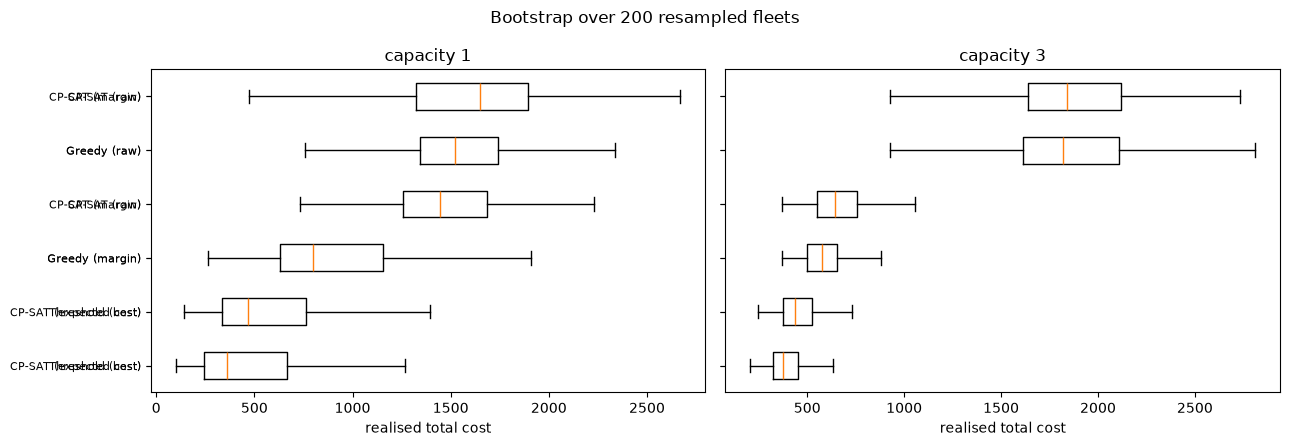

In [20]:
fig, axes = plt.subplots(1, len(bootstrap_results), figsize=(13, 4.5), sharey=True)

for ax, (cap, df) in zip(np.atleast_1d(axes), bootstrap_results.items()):
    order = df.mean().sort_values().index
    ax.boxplot([df[c] for c in order], vert=False, tick_labels=order, showfliers=False)
    ax.set_xlabel('realised total cost')
    ax.set_title(f'capacity {cap}')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Bootstrap over {N_BOOTSTRAP} resampled fleets')
plt.tight_layout()
plt.show()

In [21]:
# ---------------------------------------------------------------------------
# What the bootstrap actually supports
# ---------------------------------------------------------------------------
# 1. At capacity 3, accounting for prediction error is the dominant effect:
#    margin/expected/threshold mean costs are far below both raw strategies.
#    The paired expected-vs-raw intervals exclude zero in every comparison.
#
# 2. The expected-cost method is not better than the fixed-margin methods at
#    capacity 3: its paired intervals versus greedy/CP-SAT margin include zero.
#    It does beat the oracle-retuned threshold in these replicates, but that is
#    one policy-family comparison on one 100-engine test fleet.
#
# 3. At capacity 1, expected cost reliably beats CP-SAT with a uniform margin,
#    but it does NOT reliably beat greedy+margin or the oracle threshold: both
#    paired intervals include zero and their mean costs are lower. Therefore this
#    experiment does not justify exact optimisation over the simple heuristic.
#
# 4. The threshold is an oracle comparator, re-tuned on each replicate; it is
#    deliberately optimistic and is not a deployable result. The robust claim is
#    narrower: ignoring prediction error is costly under the stated assumptions.
final_note = pd.concat({cap: pd.DataFrame({'mean': df.mean(), 'p2.5': df.quantile(0.025),
                                           'p97.5': df.quantile(0.975)})
                        for cap, df in bootstrap_results.items()}, names=['capacity'])
final_note.round(0)

mean    p2.5   p97.5
capacity                                               
1        Greedy (raw)            1549.0   943.0  2225.0
         Greedy (margin)          924.0   350.0  1955.0
         CP-SAT (raw)            1479.0   866.0  2138.0
         CP-SAT (margin)         1640.0   766.0  2514.0
         CP-SAT (expected cost)   608.0   157.0  1603.0
         Threshold (best)         521.0   124.0  1741.0
3        Greedy (raw)            1853.0  1213.0  2604.0
         Greedy (margin)          579.0   391.0   828.0
         CP-SAT (raw)            1895.0  1236.0  2618.0
         CP-SAT (margin)          667.0   434.0  1094.0
         CP-SAT (expected cost)   391.0   237.0   627.0
         Threshold (best)         453.0   278.0   684.0